### Task 1: Profiles and QA the Data:


In [247]:
import pandas as pd

Listings = pd.read_csv(
    "Listings.csv", 
    encoding = "ISO-8859-1", 
    low_memory=False,
    parse_dates=["host_since"]
)

### Task 1: Profiling and QA the data.
1. Importing and open the listing csv file.

2. Cast any datae column correctly as datetime format.

3. Filter the data down to rows where the city are, first in Paris, and keep only the columns "host_since, neighbourhood, city, accommodates and price" in the table.

4. QA the Paris listings data, check for missing values and calculate the minimum, maximum and average for each numeric fields.

In [248]:
Listings.head(5)

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [249]:
Listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  object        
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[ns]
 4   host_location                278872 non-null  object        
 5   host_response_time           150930 non-null  object        
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  object        
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  object        
 11  host_identity_verified    

In [250]:
Listings["host_since"] = pd.to_datetime(Listings["host_since"])

Listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  object        
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[ns]
 4   host_location                278872 non-null  object        
 5   host_response_time           150930 non-null  object        
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  object        
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  object        
 11  host_identity_verified    

In [251]:
print(Listings["city"].value_counts())

city
Paris             64690
New York          37012
Sydney            33630
Rome              27647
Rio de Janeiro    26615
Istanbul          24519
Mexico City       20065
Bangkok           19361
Cape Town         19086
Hong Kong          7087
Name: count, dtype: int64


### Task 1A: Creation Paris Listings section:

In [252]:
paris_Listings = (
    Listings
    .query("city == 'Paris'")
    .loc[:, ["host_since", "neighbourhood", "city", "accommodates", "price"]]
)
paris_Listings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[ns]
 1   neighbourhood  64690 non-null  object        
 2   city           64690 non-null  object        
 3   accommodates   64690 non-null  int64         
 4   price          64690 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 3.0+ MB


In [253]:
paris_Listings.isna().sum()

host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

In [254]:
paris_Listings.describe()

,host_since,accommodates,price
count,64657,64690.000000,64690.000000
mean,2015-11-01 11:06:05.528867584,3.037997,113.096445
min,2008-08-30 00:00:00,0.000000,0.000000
25%,2014-03-09 00:00:00,2.000000,59.000000
50%,2015-07-07 00:00:00,2.000000,80.000000
75%,2017-05-29 00:00:00,4.000000,120.000000
max,2021-02-07 00:00:00,16.000000,12000.000000
std,NaN,1.588766,214.433668


In [255]:
paris_Listings.query("accommodates == 0").count()

host_since       54
neighbourhood    54
city             54
accommodates     54
price            54
dtype: int64

In [256]:
paris_Listings.query("accommodates == 0")

,host_since,neighbourhood,city,accommodates,price
98209,2020-07-20,Pantheon,Paris,0,0
203257,2020-02-04,Batignolles-Monceau,Paris,0,0
203258,2016-10-17,Opera,Paris,0,0
203259,2020-04-24,Luxembourg,Paris,0,0
203260,2020-04-24,Vaugirard,Paris,0,0
203261,2020-07-15,Batignolles-Monceau,Paris,0,0
203263,2016-06-07,Palais-Bourbon,Paris,0,0
203264,2020-09-08,Pantheon,Paris,0,0
203265,2020-09-21,Vaugirard,Paris,0,0
203267,2020-10-29,Observatoire,Paris,0,0


In [257]:
paris_Listings.query("price == 0 and accommodates == 0").count()

host_since       54
neighbourhood    54
city             54
accommodates     54
price            54
dtype: int64

Paris has 54 invalid listings with zero price and zero guest capacity.
Sydney has no such invalid listings.

### Task 1B: Creation Sydney Listings section:

In [258]:
sydney_Listings = (
    Listings
    .query("city == 'Sydney'")
    .loc[:, ["host_since", "neighbourhood", "city", "accommodates", "price"]]
)
sydney_Listings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33630 entries, 9237 to 273178
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     33596 non-null  datetime64[ns]
 1   neighbourhood  33630 non-null  object        
 2   city           33630 non-null  object        
 3   accommodates   33630 non-null  int64         
 4   price          33630 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 1.5+ MB


In [259]:
sydney_Listings.isna().sum()

host_since       34
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

In [260]:
sydney_Listings.describe()

,host_since,accommodates,price
count,33596,33630.000000,33630.000000
mean,2016-02-22 12:27:41.340635904,3.266994,222.013440
min,2009-05-14 00:00:00,1.000000,5.000000
25%,2014-08-19 00:00:00,2.000000,74.000000
50%,2016-01-05 00:00:00,2.000000,120.000000
75%,2017-10-20 00:00:00,4.000000,219.000000
max,2021-02-07 00:00:00,16.000000,28613.000000
std,NaN,2.146717,472.636189


In [261]:
sydney_Listings.query("accommodates == 0").count()

host_since       0
neighbourhood    0
city             0
accommodates     0
price            0
dtype: int64

In [262]:
sydney_Listings.query("accommodates == 0")

,host_since,neighbourhood,city,accommodates,price


In [263]:
sydney_Listings.query("price == 0 and accommodates == 0").count()

host_since       0
neighbourhood    0
city             0
accommodates     0
price            0
dtype: int64

### Task 2: Paris Preparation Visualization.
. Create a paris_Listings_neighbourhood, this group Paris listings by "neighbourhood" and calculate the mean price for each neighbourhood, sorted from highest to lowest average price.

. Create a paris_Listings_accommodations, this narrow down the most expensive neighborhood in Paris, grouped by the "accommodations" columns, and contain the mean price for each values of "accommodates" sorted from highest to lowest average price.

. Create a paris_Listings_over_time, this group the years of "host_since" column to calculate a count of rows, representing total number of new hosts, and average price for each years.


In [264]:
paris_Listings_neighbourhood = (
    paris_Listings
    .groupby("neighbourhood")
    .agg({"price":"mean"})
    .sort_values("price")
)

paris_Listings_neighbourhood.head()

,price
neighbourhood,
Menilmontant,74.942257
Buttes-Chaumont,82.690182
Buttes-Montmartre,87.209479
Reuilly,89.058402
Popincourt,90.559459


In [265]:
paris_Listings_neighbourhood.tail()

,price
neighbourhood,
Luxembourg,155.638639
Palais-Bourbon,156.856578
Passy,161.144635
Louvre,175.379972
Elysee,210.536765


In [266]:
paris_Listings_accommodates = (
    paris_Listings
    .query("neighbourhood == 'Vaugirard'")
    .groupby("accommodates")
    .agg({"price": "mean"})
    .sort_values("price")
)
paris_Listings_accommodates.head()

,price
accommodates,
0,0.000000
1,61.164751
2,84.622909
3,95.642702
16,120.000000


In [267]:
paris_Listings_accommodates.tail()

,price
accommodates,
9,316.250000
7,392.520000
12,463.500000
11,495.500000
10,720.833333


In [268]:
paris_Listings["neighbourhood"].value_counts().head(20)

neighbourhood
Buttes-Montmartre      7237
Popincourt             6206
Vaugirard              4826
Enclos-St-Laurent      4628
Batignolles-Monceau    4330
Menilmontant           3758
Buttes-Chaumont        3728
Passy                  3215
Opera                  3157
Temple                 2943
Reuilly                2654
Observatoire           2485
Gobelins               2278
Bourse                 2188
Pantheon               2140
Luxembourg             1998
Hotel-de-Ville         1972
Palais-Bourbon         1771
Elysee                 1768
Louvre                 1408
Name: count, dtype: int64

In [269]:
paris_Listings_over_time = (
    paris_Listings
    .set_index("host_since")
    .resample("YE")
    .agg({
        "neighbourhood": "count", 
        "price": "mean"
    })
)
paris_Listings_over_time.head()

,neighbourhood,price
host_since,,
2008-12-31,4,77.750000
2009-12-31,106,159.641509
2010-12-31,416,125.031250
2011-12-31,1339,124.828230
2012-12-31,4592,111.578615


### Task 2: Sydney Preparation Visualization.
. Create a sydney_Listings_neighbourhood, this group Paris listings by "neighbourhood" and calculate the mean price for each neighbourhood, sorted from highest to lowest average price.

. Create a sydney_Listings_accommodations, this narrow down the most expensive neighborhood in Paris, grouped by the "accommodations" columns, and contain the mean price for each values of "accommodates" sorted from highest to lowest average price.

. Create a sydney_Listings_over_time, this group the years of "host_since" column to calculate a count of rows, representing total number of new hosts, and average price for each years.


In [270]:
sydney_Listings_neighbourhood = (
    newyork_Listings
    .groupby("neighbourhood")
    .agg({"price":"mean"})
    .sort_values("price")
)

sydney_Listings_neighbourhood.head()

,price
neighbourhood,
Gerritsen Beach,30.000000
Soundview,47.538462
University Heights,48.125000
Port Richmond,48.666667
Hunts Point,49.695652


In [271]:
sydney_Listings_neighbourhood.tail()

,price
neighbourhood,
Briarwood,346.147059
Tribeca,373.203593
Riverdale,391.375000
Prince's Bay,397.500000
Fort Wadsworth,800.000000


In [272]:
sydney_Listings["neighbourhood"].value_counts().head(20)

neighbourhood
Sydney              8074
Waverley            4737
Randwick            3045
Warringah           1705
Manly               1631
Woollahra           1382
North Sydney        1188
Pittwater           1165
Marrickville        1111
Rockdale             855
Leichhardt           817
Botany Bay           628
Ryde                 594
Parramatta           537
Sutherland Shire     510
Mosman               480
Willoughby           477
Hornsby              425
Canada Bay           383
Auburn               377
Name: count, dtype: int64

In [273]:
sydney_Listings_accommodates = (
    sydney_Listings
    .query("neighbourhood == 'Waverley'")
    .groupby("accommodates")
    .agg({"price": "mean"})
    .sort_values("price")
)
sydney_Listings_accommodates.head()

,price
accommodates,
1,77.927907
2,141.291607
3,170.861702
4,253.971055
5,337.823256


In [274]:
sydney_Listings_accommodates.tail()

,price
accommodates,
8,1030.871622
9,1069.473684
16,1071.000000
10,1132.848485
14,1500.000000


In [275]:
sydney_Listings_over_time = (
    sydney_Listings
    .set_index("host_since")
    .resample("YE")
    .agg({
        "neighbourhood": "count", 
        "price": "mean"
    })
)
sydney_Listings_over_time.head()

,neighbourhood,price
host_since,,
2009-12-31,25,1333.680000
2010-12-31,198,354.580808
2011-12-31,587,201.347530
2012-12-31,1755,255.549858
2013-12-31,2963,247.508606


### Task 3: Visualize Data.

. Create horizontal bar charts of average price by neighborhood in Paris, with titlle and axis labels.

. Create horizontal bar charts of average price by "accommodates in Paris" most expensive neighborhood, add title and change axis labels.

. Create two line charts: One of count of new hosts over time, and one for average price, make sure to set the y-axis limit to 0, add a title and change axis labels.

. Base on the finding, what insight do you have the impact of 2015 regulations on new hosts and prices.

<Axes: ylabel='neighbourhood'>

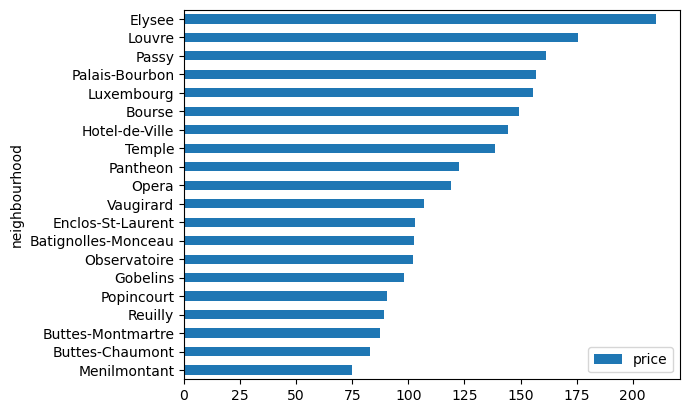

In [276]:
(paris_Listings_neighbourhood
.plot
.barh()
)

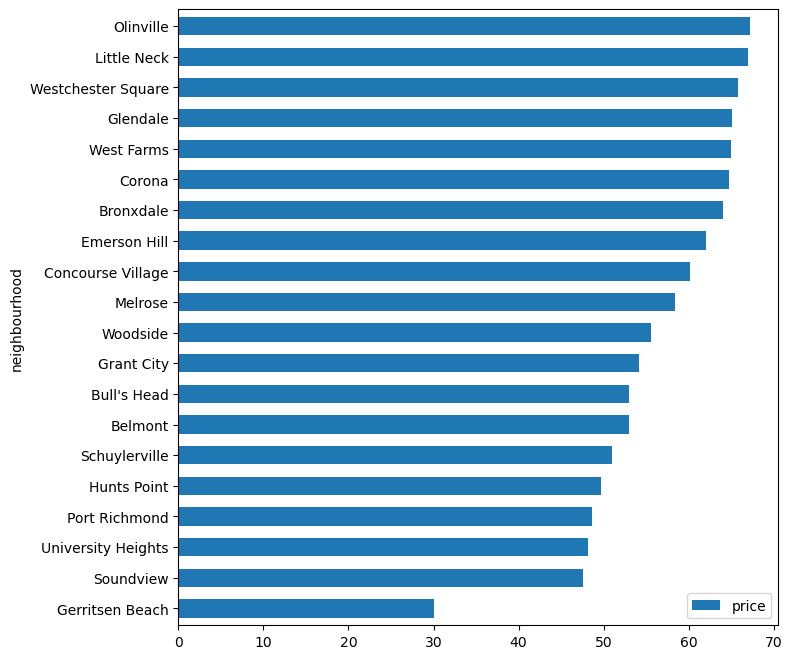

In [277]:
import matplotlib.pyplot as plt
sydney_Listings_neighbourhood.head(20).plot.barh(
    figsize=(12, 8),
    width=0.6
)

plt.subplots_adjust(left=0.4)
plt.show()

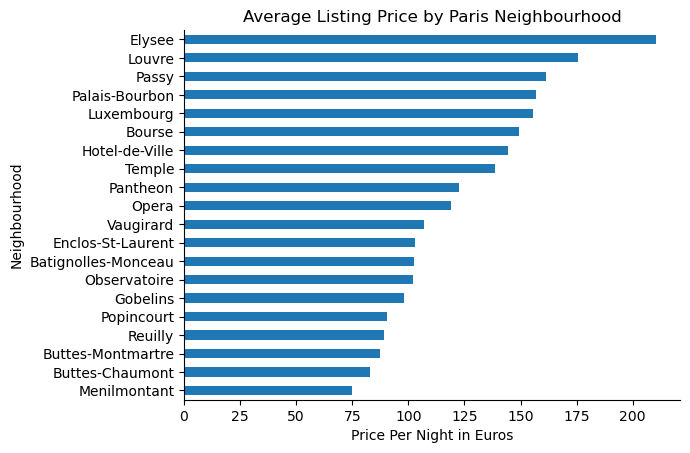

In [278]:
import seaborn as sns

(paris_Listings_neighbourhood
.plot
.barh(
    title = "Average Listing Price by Paris Neighbourhood",
    xlabel = "Price Per Night in Euros",
    ylabel = "Neighbourhood",
    legend=None
)
)

sns.despine()

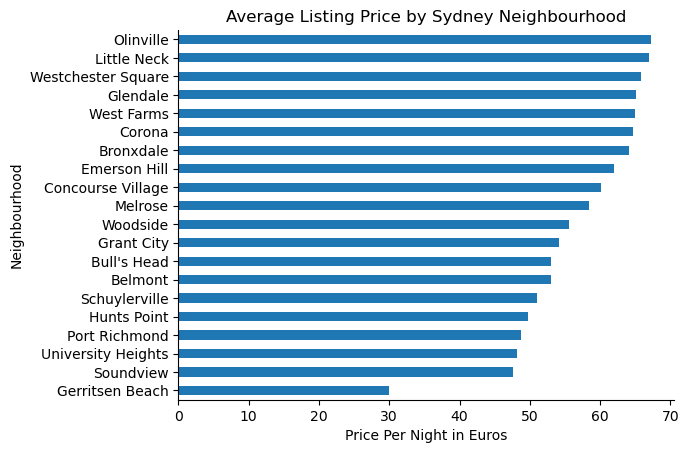

In [279]:
import seaborn as sns

(sydney_Listings_neighbourhood
.head(20)
.plot
.barh(
    title = "Average Listing Price by Sydney Neighbourhood",
    xlabel = "Price Per Night in Euros",
    ylabel = "Neighbourhood",
    legend=None
)
)

sns.despine()

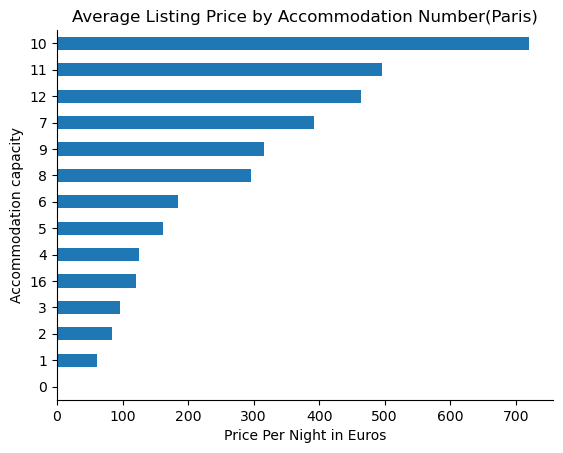

In [280]:
(paris_Listings_accommodates
.plot
.barh(
    title = "Average Listing Price by Accommodation Number(Paris)",
    xlabel = "Price Per Night in Euros",
    ylabel = "Accommodation capacity",
    legend=None
)
)

sns.despine()

In [281]:
print(type(sydney_Listings_accommodates))
print(sydney_Listings_accommodates.head())
print(sydney_Listings_accommodates.shape)
print(sydney_Listings_accommodates.dtypes)

<class 'pandas.core.frame.DataFrame'>
                   price
accommodates            
1              77.927907
2             141.291607
3             170.861702
4             253.971055
5             337.823256
(15, 1)
price    float64
dtype: object


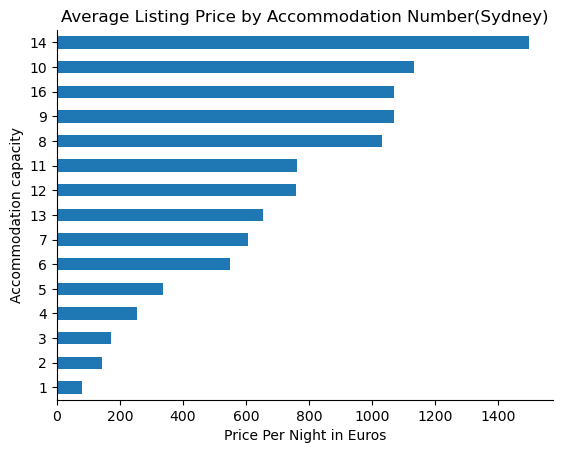

In [282]:
(sydney_Listings_accommodates
.plot
.barh(
    title = "Average Listing Price by Accommodation Number(Sydney)",
    xlabel = "Price Per Night in Euros",
    ylabel = "Accommodation capacity",
    legend=None
)
)

sns.despine()

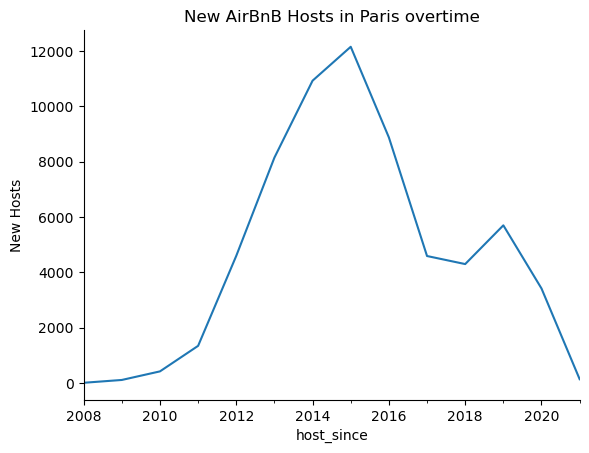

In [283]:
paris_Listings_over_time["neighbourhood"].plot(
    ylabel = "New Hosts",
    title = "New AirBnB Hosts in Paris overtime"
)
sns.despine()

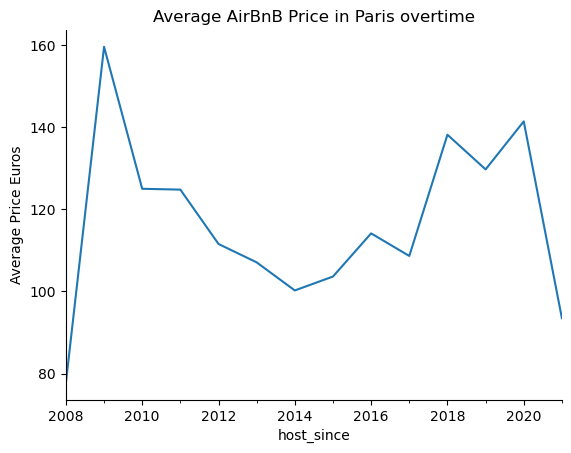

In [284]:
paris_Listings_over_time["price"].plot(
    ylabel = "Average Price Euros",
    title = "Average AirBnB Price in Paris overtime"
)
sns.despine()

Text(0.5, 1.0, '2015 Paris Regulation Lead to Fewer New Hosts and Higher Prices ')

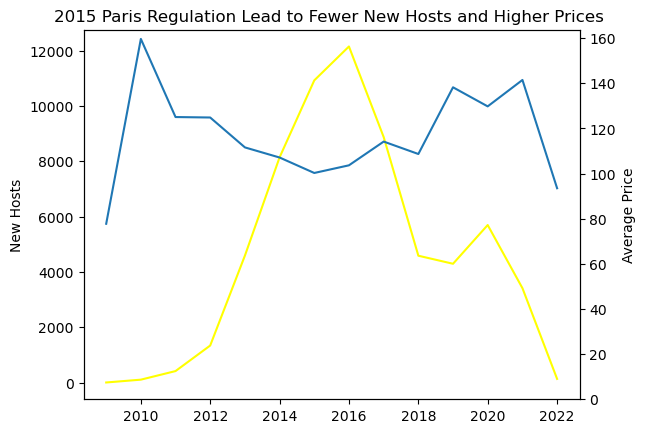

In [285]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(
    paris_Listings_over_time.index,
    paris_Listings_over_time["neighbourhood"],
    label = "New Hosts",
    c = "Yellow"
)
ax.set_ylabel("New Hosts")

ax2 = ax.twinx()
ax2.plot(
    paris_Listings_over_time.index,
    paris_Listings_over_time["price"],
    label = "Average Price",
)
ax2.set_ylim(0)
ax2.set_ylabel("Average Price")

ax.set_title("2015 Paris Regulation Lead to Fewer New Hosts and Higher Prices ")

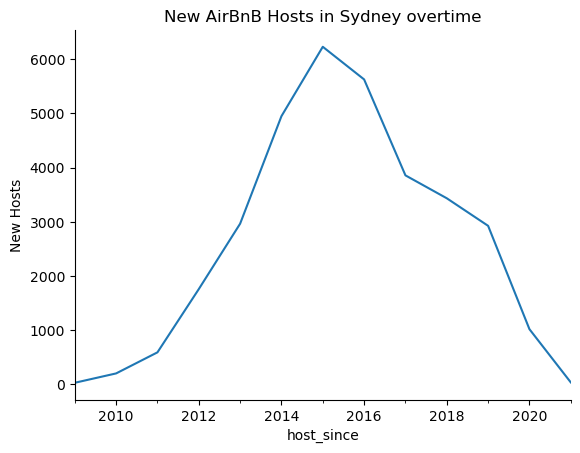

In [286]:
sydney_Listings_over_time["neighbourhood"].plot(
    ylabel = "New Hosts",
    title = "New AirBnB Hosts in Sydney overtime"
)
sns.despine()

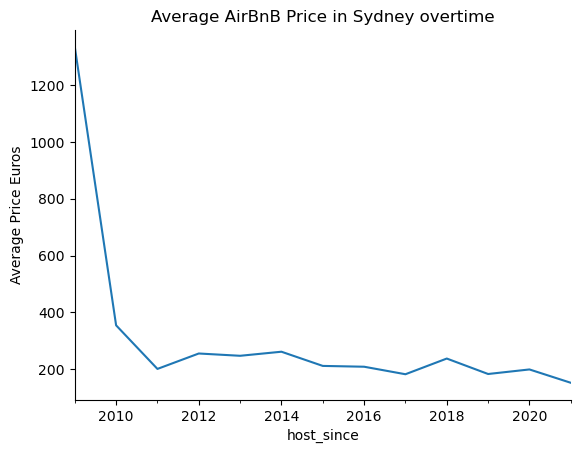

In [287]:
sydney_Listings_over_time["price"].plot(
    ylabel = "Average Price Euros",
    title = "Average AirBnB Price in Sydney overtime"
)
sns.despine()

Text(0.5, 1.0, '2015 Sydney Regulation Lead to More New Hosts and Lower Prices ')

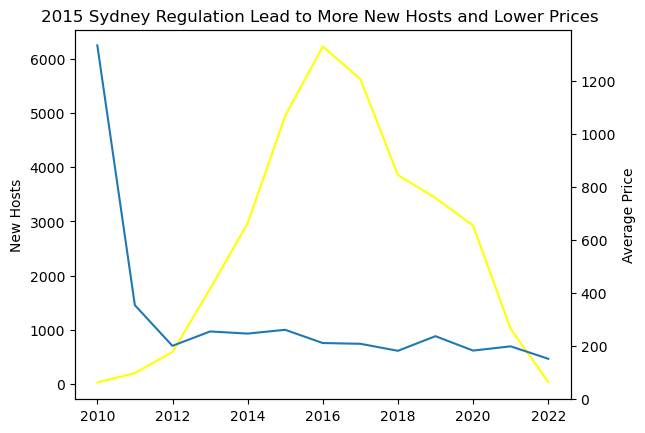

In [288]:
fig, ax = plt.subplots()
ax.plot(
    sydney_Listings_over_time.index,
    sydney_Listings_over_time["neighbourhood"],
    label = "New Hosts",
    c = "Yellow"
)
ax.set_ylabel("New Hosts")

ax2 = ax.twinx()
ax2.plot(
    sydney_Listings_over_time.index,
    sydney_Listings_over_time["price"],
    label = "Average Price",
)
ax2.set_ylim(0)
ax2.set_ylabel("Average Price")

ax.set_title("2015 Sydney Regulation Lead to More New Hosts and Lower Prices ")